In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!ls "/content/drive/MyDrive/Colab Notebooks"

'Copy of NN.ipynb'   RVM-Detection_model.ipynb	 TF_and_ANNs.ipynb
 NN.ipynb	     RVM.v5i.yolov8.zip


In [4]:
zip_path = "/content/drive/MyDrive/Colab Notebooks/RVM.v5i.yolov8.zip"

!mkdir -p /content/RVM
!unzip -q "$zip_path" -d /content/RVM

In [5]:
!ls /content/RVM

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [6]:
!cat /content/RVM/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['CAN', 'PET']

roboflow:
  workspace: rvm-vzvbe
  project: rvm-wlxnq
  version: 5
  license: CC BY 4.0
  url: https://universe.roboflow.com/rvm-vzvbe/rvm-wlxnq/dataset/5

In [7]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.8 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [9]:
!yolo task=detect mode=train \
  model=yolov8s.pt \
  data=/content/RVM/data.yaml \
  epochs=50 \
  imgsz=512 \
  batch=16 \
  name=rvm_yolov8s_v1

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RVM/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=rvm_yolov8s_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

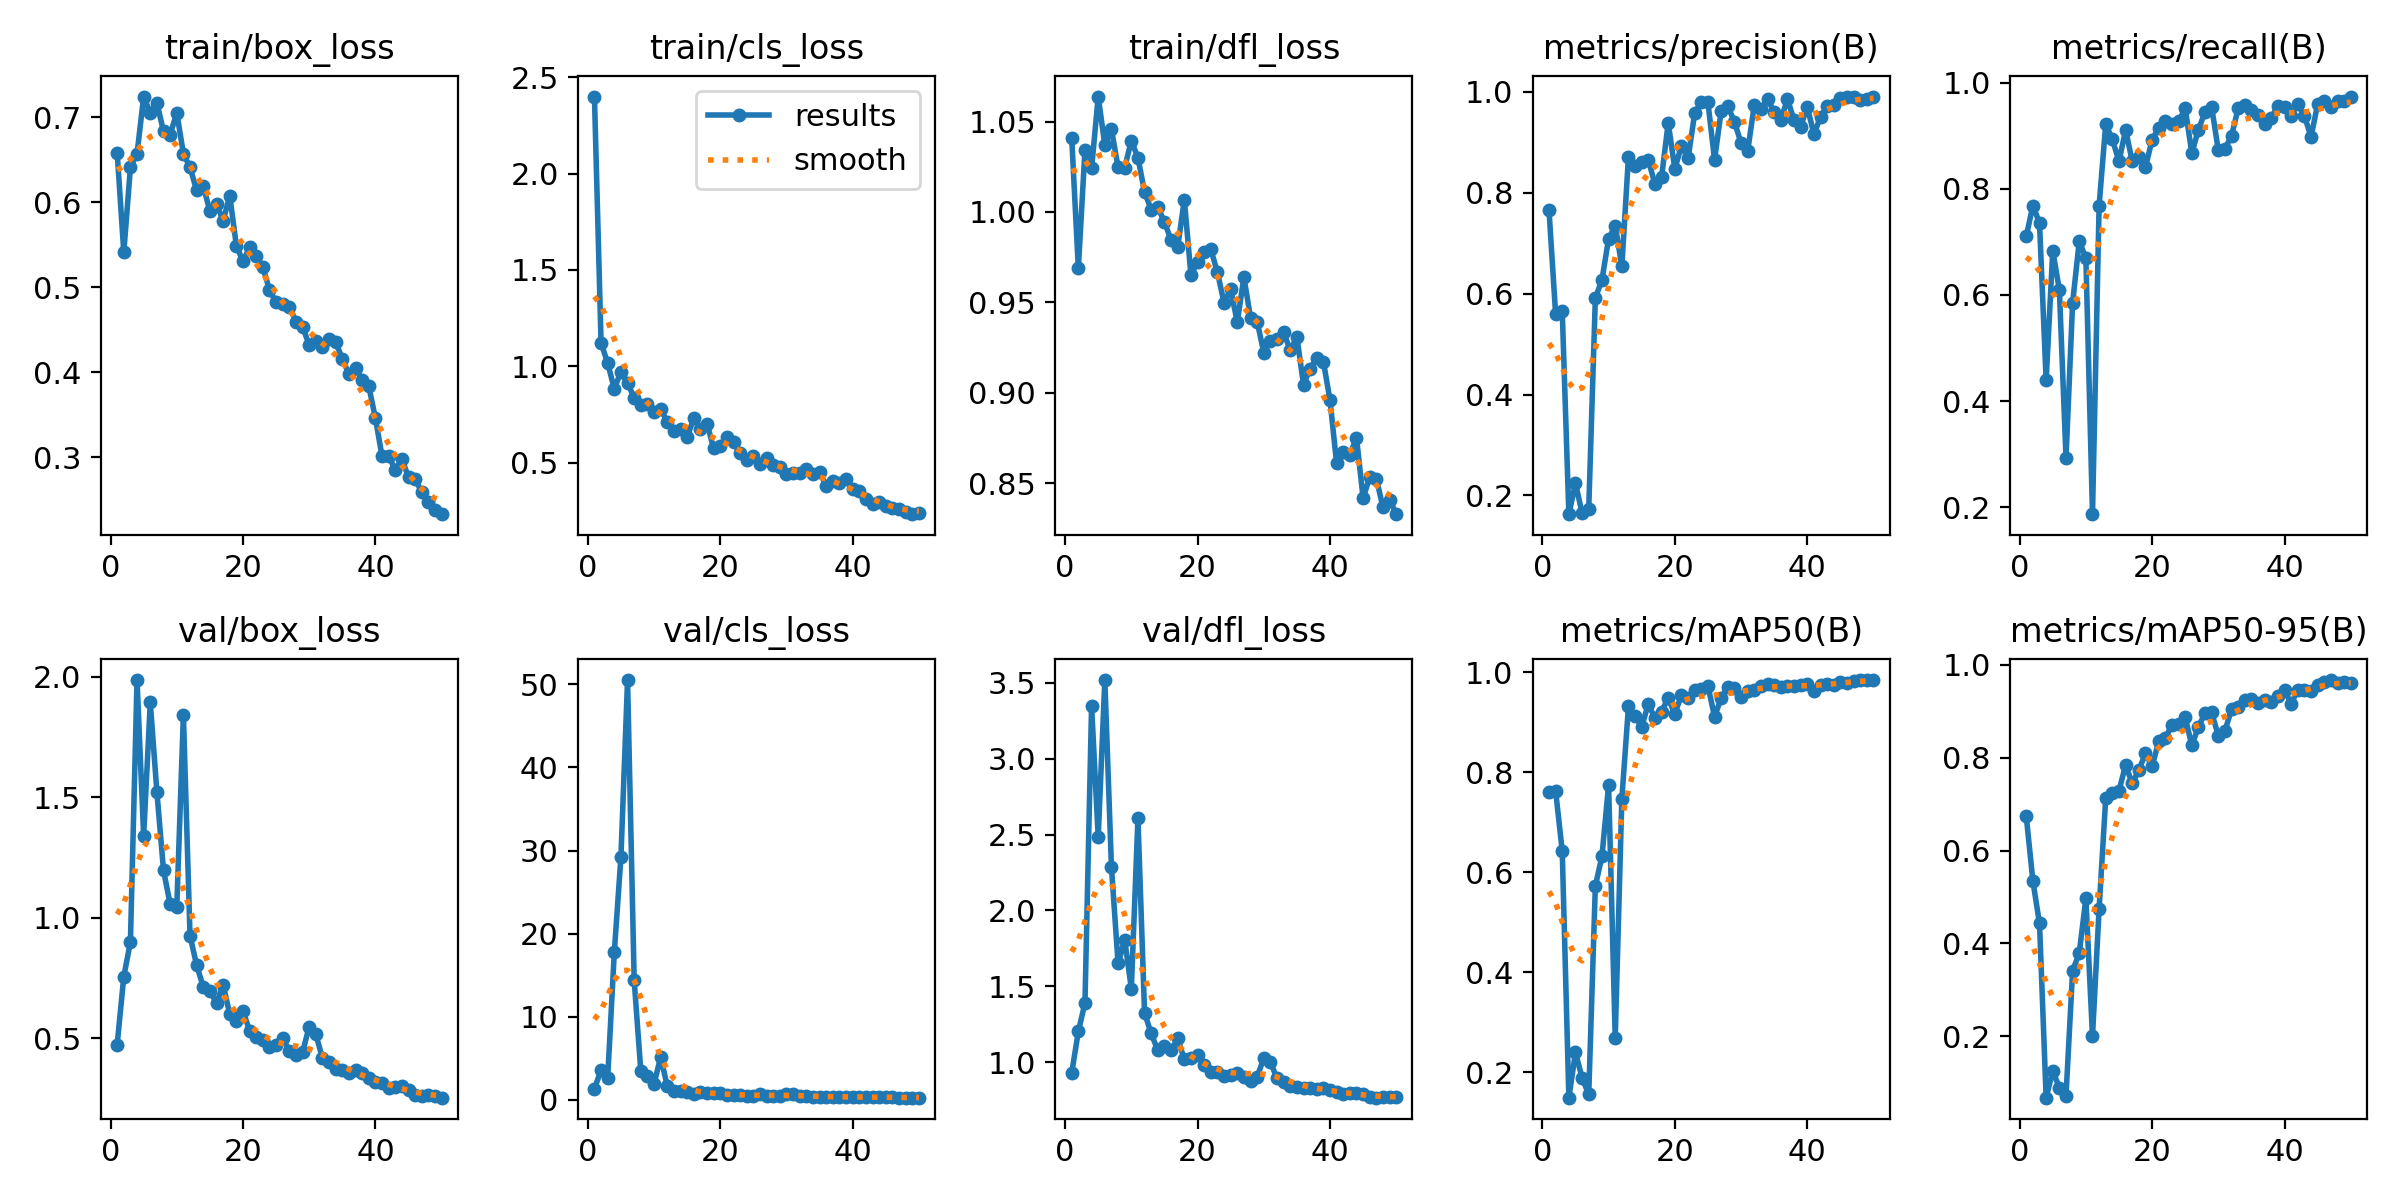

In [10]:
from IPython.display import Image, display

display(Image(filename="runs/detect/rvm_yolov8s_v1/results.png"))

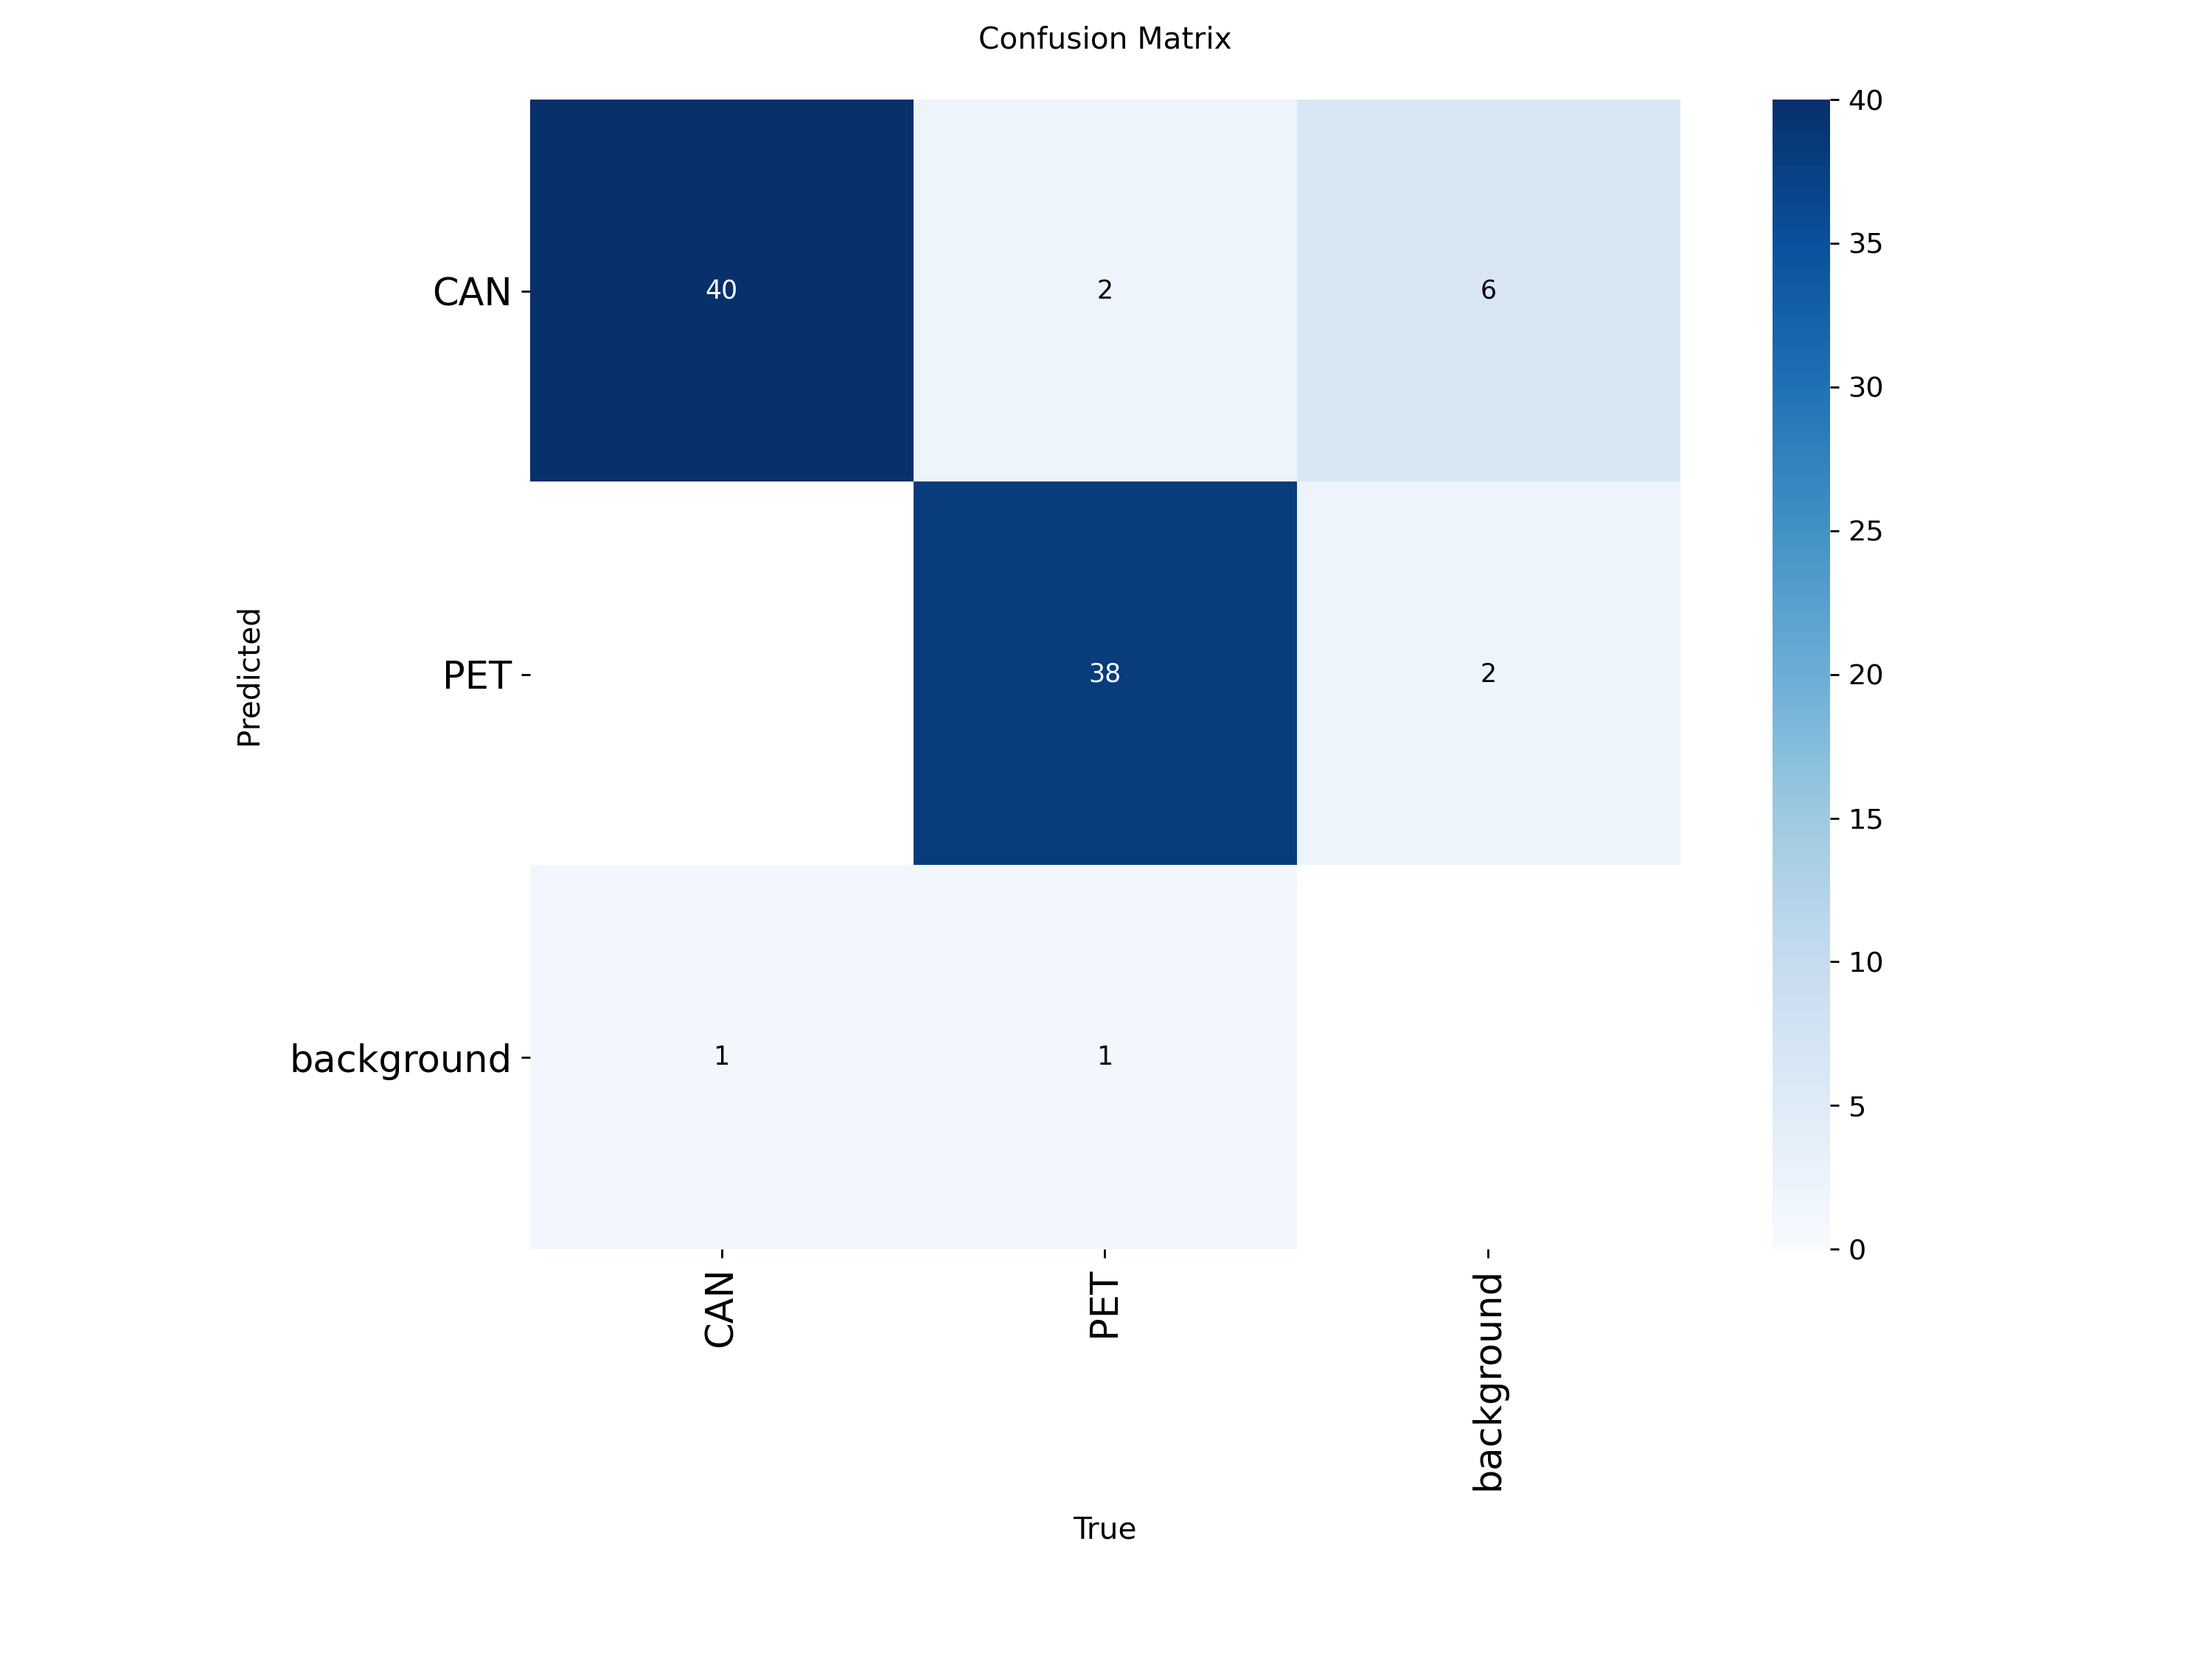

In [11]:
display(Image(filename="runs/detect/rvm_yolov8s_v1/confusion_matrix.png"))

In [12]:
!yolo task=detect mode=val \
  model=/content/runs/detect/rvm_yolov8s_v1/weights/best.pt \
  data=/content/RVM/data.yaml \
  split=test

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 12.6±9.8 MB/s, size: 39.6 KB)
val: Scanning /content/RVM/test/labels... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 876.0it/s 0.0s
val: New cache created: /content/RVM/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.7it/s 1.1s
                   all         40         42      0.972      0.979       0.98      0.958
                   CAN         22         24          1      0.958      0.964      0.939
                   PET         18         18      0.944          1      0.995      0.976
Speed: 5.3ms preprocess, 9.8ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [13]:
!cp /content/runs/detect/rvm_yolov8s_v1/weights/best.pt "/content/drive/MyDrive/rvm_best_yolov8s.pt"

In [14]:
!yolo task=detect mode=predict \
  model=/content/runs/detect/rvm_yolov8s_v1/weights/best.pt \
  source=/content/RVM/test/images \
  imgsz=512 \
  save=True

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/40 /content/RVM/test/images/AluCan1-007_jpg.rf.d26d4b1261a2a136b7620eb6c748c72f.jpg: 512x512 1 CAN, 11.1ms
image 2/40 /content/RVM/test/images/AluCan1-012_jpg.rf.4748b91ab817ca692c5e1c006c295c43.jpg: 512x512 2 CANs, 11.0ms
image 3/40 /content/RVM/test/images/AluCan1-019_jpg.rf.80e5f96a9f7dfcf7b9d9d2fb30d5d717.jpg: 512x512 1 CAN, 11.0ms
image 4/40 /content/RVM/test/images/AluCan1-031_jpg.rf.2c05235362b51dcb5c601a8b34f86922.jpg: 512x512 1 CAN, 11.0ms
image 5/40 /content/RVM/test/images/AluCan1-052_jpg.rf.54822a134a95c184606f624c5e0fdd1e.jpg: 512x512 1 CAN, 11.0ms
image 6/40 /content/RVM/test/images/AluCan1-056_jpg.rf.863a6bad1e87b911c79dd17411e0af3f.jpg: 512x512 1 CAN, 11.0ms
image 7/40 /content/RVM/test/images/AluCan1-057_jpg.rf.92a177ff986727ea87344b82d9ee402c.jpg: 512x512 1 CAN, 11.0ms
image 8/40 /content/RVM/test